# Filtros.03-Projeto

O nosso objetivo é o de limpar as imagens do cameraman com ruido e comparar com a original.

Original | Ruido | Ruido2
:---:|:---:|:---:
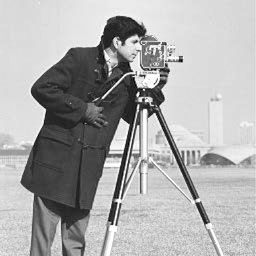 | 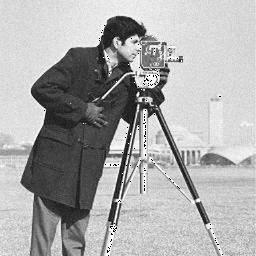 | 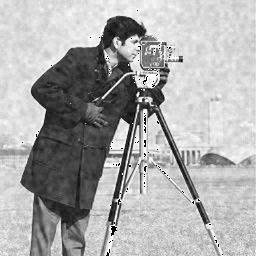

Temos o sinal (imagem), devemos construir o grafo. Primeiro, construir um grafo simples, i.e. com peso unitário, conectando um pixel com os oito imediatamente próximos.

Filtrar com: heat (com diferentes parámetros); regularização à Tikhonov. Podem usar as  versões  já implementadas no PyGSP, mas podem tentar implementar as suas.

Comparar a qualidade da imagem filtrada com a original usando 3 métricas:
1) olho nu;
2) erro quadrático medio (MSE);
3) peak signal-to-noise ratio (PSNR).
As métricas 2) e 3) estão descritas na Wikipedia em
https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio
Existem implementações das duas métricas em alguns módulos Python, procurar ou implementá- las.


Em caso que implementem algum filtro, comparem a performance do tempo de execução (como mostrado na aula de hoje) com o da implementação do PyGSP.

Agora, vamos a construir outro grafo, seguindo a sugestão de Shuman et al, IEEE Signals Processing Magazine 2013 (Example 2, pag. 90). Em outras palabras, construir um grafo com peso, onde o peso leva em conta o "gradiente de cinza" da imagem. 

Como antes, filtrar com: heat (com diferentes parámetros); regularização à Tikhonov.

**Entrega:** *Jupyter ou .py com código usado. Discutir resultados. Uma tabela comparando os valores obtidos nas diferentes métricas é desejável.* **Prazo: flexivel, mas sem abusar**

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from pygsp import graphs, filters, utils
import time

from PIL import Image, ImageFilter
# from scipy.linalg import eigh
from scipy.ndimage import uniform_filter, median_filter

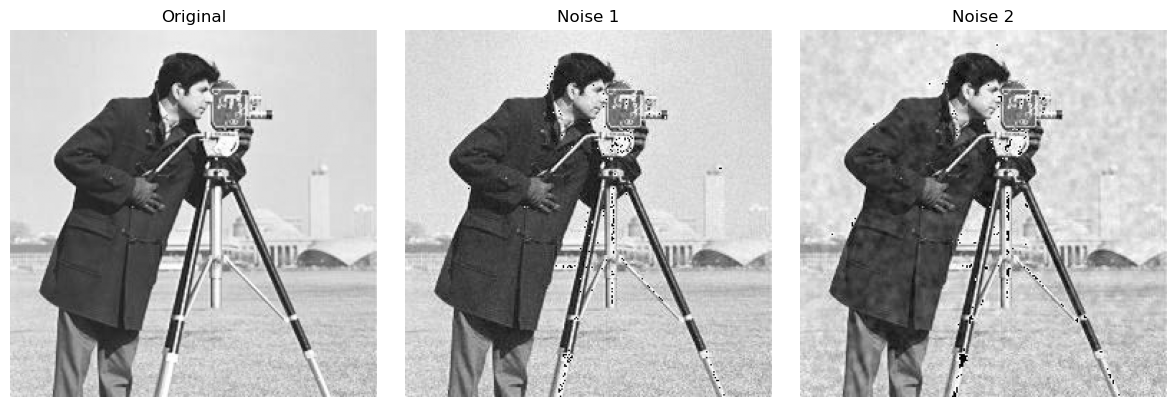

In [89]:
original_image = np.array(Image.open('./data/original.jpg'))
noisy_1_image = np.array(Image.open('./data/noisy-1.jpg'))
noisy_2_image = np.array(Image.open('./data/noisy-2.jpg'))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(noisy_1_image, cmap='gray')
axes[1].set_title('Noise 1')
axes[1].axis('off')

axes[2].imshow(noisy_2_image, cmap='gray')
axes[2].set_title('Noise 2')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [90]:
H, W = original_image.shape

G = graphs.Grid2d(H, W, diagonal=True)

print(H, W)

256 256


In [91]:
# G.set_coordinates(kind='random2D')
# G.plot(vertex_size=1, edges=False)
# plt.show()

# Not informative what so ever.

In [92]:
def compute_relative_rmse(img, ref):
    scale = np.max(ref) - np.min(ref)
    return np.sqrt(np.mean((img - ref) ** 2)) / scale

import numpy as np

def psnr(image, reference, data_range=None):
    image = np.asarray(image, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)
    
    mse = np.mean((image - reference) ** 2)
    
    if mse == 0:
        return np.inf  # perfect reconstruction
    
    if data_range is None:
        data_range = reference.max() - reference.min()
    
    return 10 * np.log10((data_range ** 2) / mse)

In [93]:
def run_heat_experiment(G, noisy_image, original_image, variances):
    x = noisy_image.reshape(-1)
    H, W = noisy_image.shape
    
    rmse = []
    psnr_values = []
    
    for var in variances:
        filtered = filters.Heat(G, scale=var).filter(x).reshape(H, W)
        
        rmse.append(compute_relative_rmse(filtered, original_image))
        psnr_values.append(psnr(filtered, original_image))
    
    best_rmse_idx = np.argmin(rmse)
    best_psnr_idx = np.argmax(psnr_values)
    
    best_var_rmse = variances[best_rmse_idx]
    best_var_psnr = variances[best_psnr_idx]
    
    best_filtered_rmse = filters.Heat(G, scale=best_var_rmse).filter(x).reshape(H, W)
    best_filtered_psnr = filters.Heat(G, scale=best_var_psnr).filter(x).reshape(H, W)
    
    return rmse, best_var_rmse, best_filtered_rmse, psnr_values, best_var_psnr, best_filtered_psnr

def run_cheby_experiment(G, noisy_image, original_image, degrees, g):
    x = noisy_image.reshape(-1)
    H, W = noisy_image.shape
    
    filt_g = filters.Filter(G, g)
    rmse = []
    psnr_values = []
    
    for m in degrees:
        c = filters.approximations.compute_cheby_coeff(filt_g, m=m)
        filtered = filters.approximations.cheby_op(G, c, x).reshape(H, W)
        
        rmse.append(compute_relative_rmse(filtered, original_image))
        psnr_values.append(psnr(filtered, original_image))
    
    best_rmse_idx = np.argmin(rmse)
    best_psnr_idx = np.argmax(psnr_values)
    
    best_m_rmse = degrees[best_rmse_idx]
    best_m_psnr = degrees[best_psnr_idx]
    
    # recompute best images
    c_rmse = filters.approximations.compute_cheby_coeff(filt_g, m=best_m_rmse)
    best_filtered_rmse = filters.approximations.cheby_op(G, c_rmse, x).reshape(H, W)
    
    c_psnr = filters.approximations.compute_cheby_coeff(filt_g, m=best_m_psnr)
    best_filtered_psnr = filters.approximations.cheby_op(G, c_psnr, x).reshape(H, W)
    
    return rmse, best_m_rmse, best_filtered_rmse, psnr_values, best_m_psnr, best_filtered_psnr


def run_spatial_experiment(noisy_image, original_image, sizes, method='mean'):
    H, W = noisy_image.shape
    
    rmse = []
    psnr_values = []
    
    for s in sizes:
        if method == 'mean':
            filtered = uniform_filter(noisy_image, size=s)
        elif method == 'median':
            filtered = median_filter(noisy_image, size=s)
        else:
            raise ValueError("method must be 'mean' or 'median'")
        
        rmse.append(compute_relative_rmse(filtered, original_image))
        psnr_values.append(psnr(filtered, original_image))
    
    best_rmse_idx = np.argmin(rmse)
    best_psnr_idx = np.argmax(psnr_values)
    
    best_size_rmse = sizes[best_rmse_idx]
    best_size_psnr = sizes[best_psnr_idx]
    
    # recompute best images
    if method == 'mean':
        best_filtered_rmse = uniform_filter(noisy_image, size=best_size_rmse)
        best_filtered_psnr = uniform_filter(noisy_image, size=best_size_psnr)
    else:
        best_filtered_rmse = median_filter(noisy_image, size=best_size_rmse)
        best_filtered_psnr = median_filter(noisy_image, size=best_size_psnr)
    
    return rmse, best_size_rmse, best_filtered_rmse, psnr_values, best_size_psnr, best_filtered_psnr


In [94]:
def plot_error(x_vals, error, xlabel, ylabel, title):
    plt.plot(x_vals, error, marker='o')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

def show_images(original, noisy, filtered, title_filtered):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    axes[1].imshow(noisy, cmap='gray')
    axes[1].set_title('Noisy')
    axes[1].axis('off')
    
    axes[2].imshow(filtered, cmap='gray')
    axes[2].set_title(title_filtered)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
results = {
    'heat': [],
    'cheby': [],
    'mean': [],
    'median': []
}

sizes = [3, 5, 7, 9, 11]
variances = np.linspace(0.1, 2, 100)
degrees = list(range(1, 10))
g = lambda x: 1 / (1 + x)

for i, noisy in enumerate([noisy_1_image, noisy_2_image], start=1):

    # ---- Heat ----
    rmse, best_var_rmse, best_img_rmse, psnr_vals, best_var_psnr, best_img_psnr = \
        run_heat_experiment(G, noisy, original_image, variances)

    results['heat'].append({
        'rmse': rmse,
        'psnr': psnr_vals,
        'x': variances,
        'best_img': best_img_psnr,  # choose PSNR-opt
        'label': f'Noise {i}'
    })

    # ---- Cheby ----
    rmse, best_m_rmse, best_img_rmse, psnr_vals, best_m_psnr, best_img_psnr = \
        run_cheby_experiment(G, noisy, original_image, degrees, g)

    results['cheby'].append({
        'rmse': rmse,
        'psnr': psnr_vals,
        'x': degrees,
        'best_img': best_img_psnr,
        'label': f'Noise {i}'
    })

    # ---- Mean ----
    rmse, best_s_rmse, best_img_rmse, psnr_vals, best_s_psnr, best_img_psnr = \
        run_spatial_experiment(noisy, original_image, sizes, method='mean')

    results['mean'].append({
        'rmse': rmse,
        'psnr': psnr_vals,
        'x': sizes,
        'best_img': best_img_psnr,
        'label': f'Noise {i}'
    })

    # ---- Median ----
    rmse, best_s_rmse, best_img_rmse, psnr_vals, best_s_psnr, best_img_psnr = \
        run_spatial_experiment(noisy, original_image, sizes, method='median')

    results['median'].append({
        'rmse': rmse,
        'psnr': psnr_vals,
        'x': sizes,
        'best_img': best_img_psnr,
        'label': f'Noise {i}'
    })

2026-04-05 16:55:00,799:[WARNING](pygsp.graphs.graph.lmax): The largest eigenvalue G.lmax is not available, we need to estimate it. Explicitly call G.estimate_lmax() or G.compute_fourier_basis() once beforehand to suppress the warning.


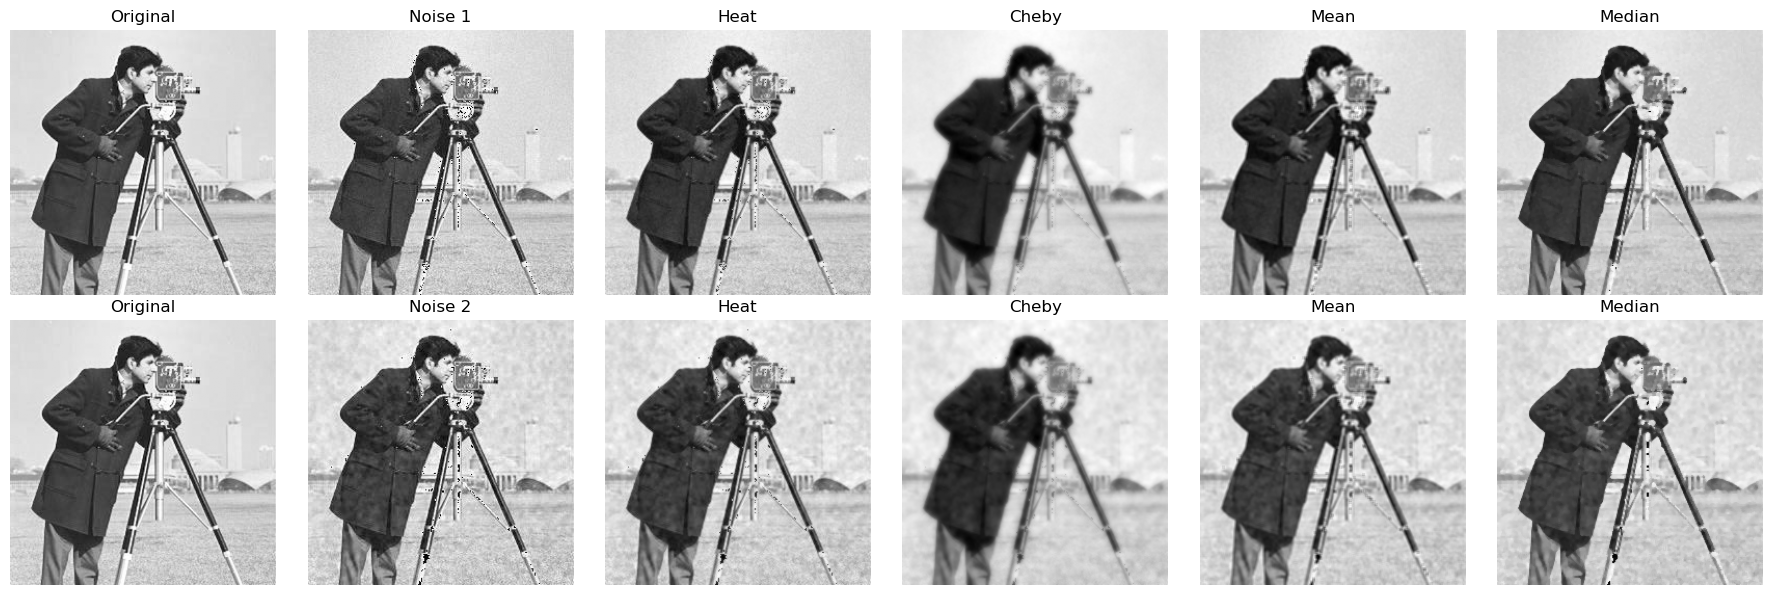

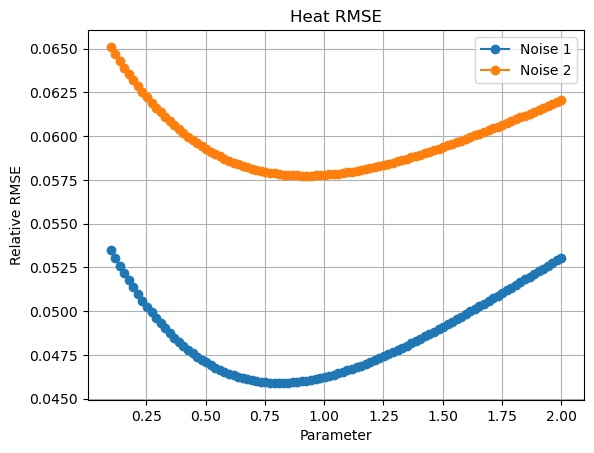

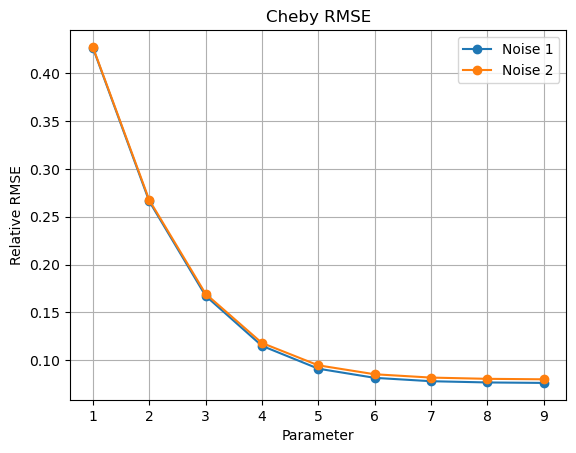

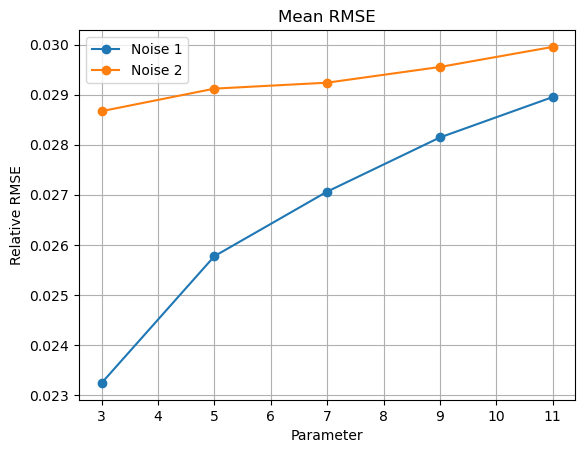

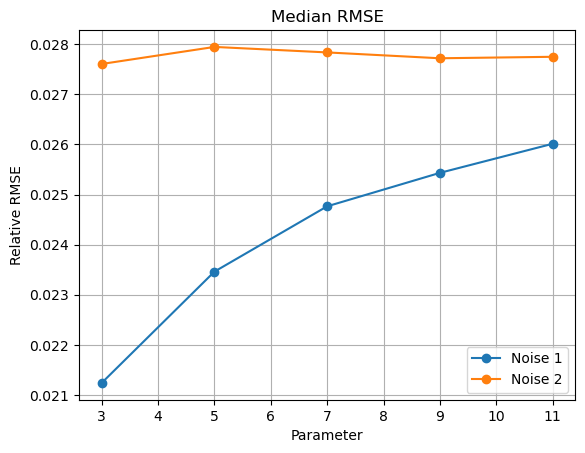

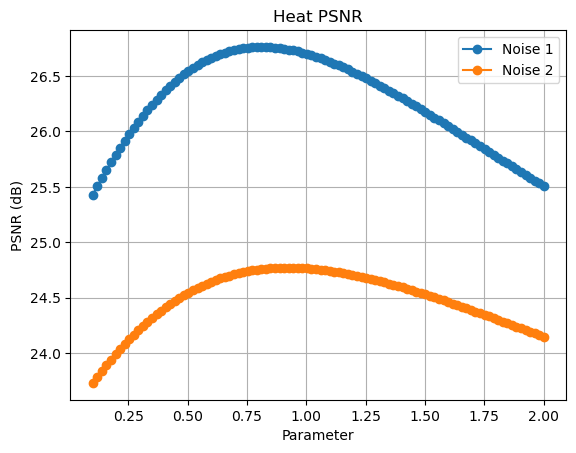

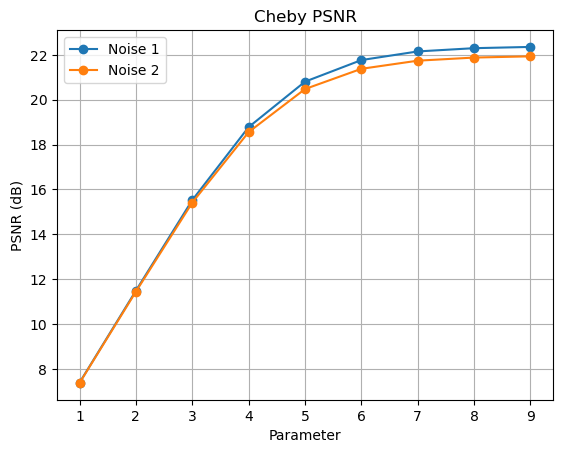

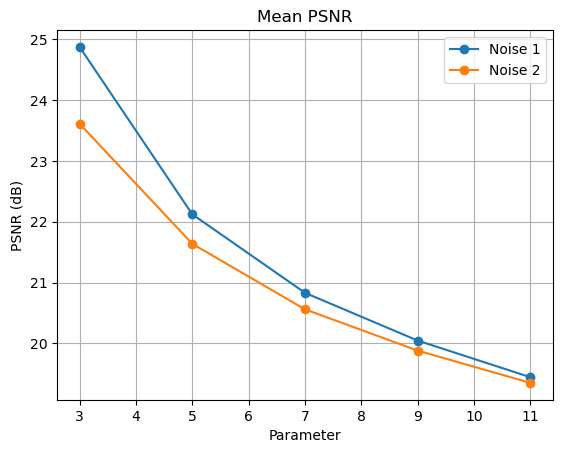

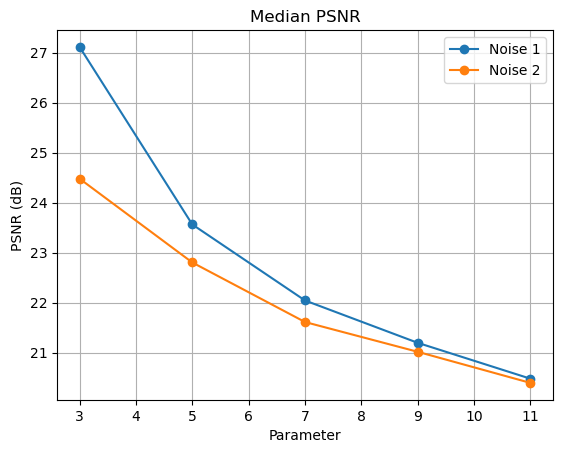

In [101]:
def show_comparison_grid(original, noisy_images, results):
    methods = ['heat', 'cheby', 'mean', 'median']
    
    n_rows = len(noisy_images)
    n_cols = 2 + len(methods)  # original + noisy + methods
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    
    for i, noisy in enumerate(noisy_images):
        
        # Original
        axes[i, 0].imshow(original, cmap='gray')
        axes[i, 0].set_title('Original')
        axes[i, 0].axis('off')
        
        # Noisy
        axes[i, 1].imshow(noisy, cmap='gray')
        axes[i, 1].set_title(f'Noise {i+1}')
        axes[i, 1].axis('off')
        
        # Methods
        for j, method in enumerate(methods):
            img = results[method][i]['best_img']
            axes[i, j+2].imshow(img, cmap='gray')
            axes[i, j+2].set_title(method.capitalize())
            axes[i, j+2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
def plot_all_rmse(results):
    for method, runs in results.items():
        plt.figure()
        
        for r in runs:
            plt.plot(r['x'], r['rmse'], marker='o', label=r['label'])
        
        plt.xlabel('Parameter')
        plt.ylabel('Relative RMSE')
        plt.title(f'{method.capitalize()} RMSE')
        plt.legend()
        plt.grid(True)
        plt.show()
        
def plot_all_psnr(results):
    for method, runs in results.items():
        plt.figure()
        
        for r in runs:
            plt.plot(r['x'], r['psnr'], marker='o', label=r['label'])
        
        plt.xlabel('Parameter')
        plt.ylabel('PSNR (dB)')
        plt.title(f'{method.capitalize()} PSNR')
        plt.legend()
        plt.grid(True)
        plt.show()
    
show_comparison_grid(original_image, [noisy_1_image, noisy_2_image], results)
plot_all_rmse(results)
plot_all_psnr(results)


## Well Let's try a weighted graph now